# QFT compiler time scaling

This notebook investigates the time scaling of the swap-less compiler for both the QFT and the QAOA.

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from Scripts.QFT_gates import (
    generate_standard_qft_gates,
    decompose_h_cphase_to_rx_rz,
    compress_rx_rz_operations,
)
from Scripts.QFT_spanning_lines import generate_lhz_spanning_lines_left_to_right
from Scripts.QFT_compiler import compile_qft_with_lhz_spanning_lines
from Scripts.Circuit_plotter import draw_compiled_ops_pennylane

from Scripts.QAOA_gates import (generate_qaoa_up_gates, generate_qaoa_ux_gates)
from Scripts.QAOA_spanning_lines import (generate_qaoa_up_lhz_spanning_lines, 
                                generate_qaoa_ux_lhz_spanning_lines)

from Scripts.QAOA_compiler import (compile_qaoa_up_with_lhz_spanning_lines,
                           compile_qaoa_ux_with_lhz_spanning_lines)

import time
from matplotlib import pyplot as plt
import numpy as np

# QFT

In [ ]:
n_list = [2,5,10]
time_list_qft = []

for n in n_list:
    start = time.time()
    qft_gates = generate_standard_qft_gates(n)
    rx_rz_gates = decompose_h_cphase_to_rx_rz(qft_gates)

    compressed_gates = compress_rx_rz_operations(rx_rz_gates)

    spanning_data = generate_lhz_spanning_lines_left_to_right(
        n,
        return_cnot_steps=True,
        verbose=False,
    )

    compiled_ops, debug = compile_qft_with_lhz_spanning_lines(
        compressed_gates,
        n,
        spanning_data=spanning_data,
        return_debug=True,
        verbose=False,
    )
    stop = time.time()
    time_list_qft.append(stop-start)
    
    with open('Data/qft_times.txt','w') as f:
        for idx, t in enumerate(time_list_qft):
            f.write(f'{n_list[idx]},{str(t)}')
            f.write('\n')

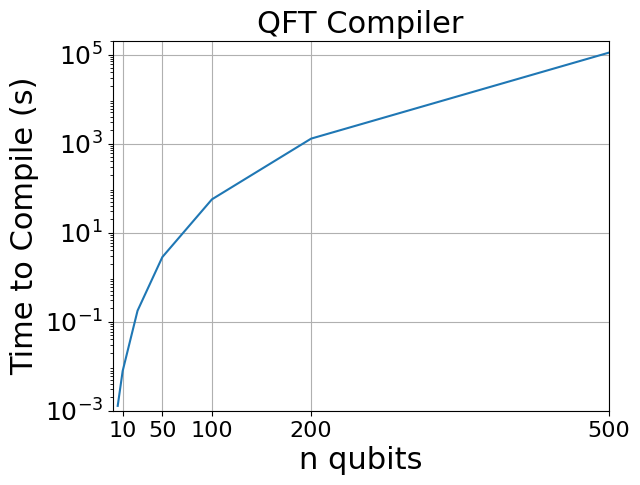

In [2]:
n_list = [5,10,25,50,100,200,500]

time_list_qft = []
with open('Data/qft_times.txt','r') as f:
    for line in f.readlines():
        time_list_qft.append(float(line.split(',')[1]))


plt.plot(n_list, time_list_qft)
plt.title('QFT Compiler', fontsize = 22)
plt.ylabel('Time to Compile (s)', fontsize = 22)
plt.yscale('log')
plt.xlabel('n qubits', fontsize = 22)
plt.xticks([10, 50, 100, 200, 500], [10, 50, 100, 200, 500], fontsize = 16)
plt.grid()
plt.ylim((1e-3,2e5))
plt.xlim((0,500))
plt.yticks([1e-3, 1e-1, 1e1, 1e3, 1e5], fontsize = 18)
plt.savefig('Figures/time_qft.pdf', bbox_inches='tight')

# QAOA - $U_P$

In [ ]:
n_list = [5,10,25,50,100,200]
gamma = 1
time_list_qaoa_up = []

for n in n_list:
    print(n)
    h_idx = np.arange(1,n+1)
    J_idx = np.zeros((n, n), dtype=int)

    counter = n+1
    for k in range(n):
        for j in range(k):
            J_idx[j, k] = int(str(j + 1)+str(k + 1))
            J_idx[k, j] = int(str(j + 1)+str(k + 1))
            counter += 1

    start = time.time()   
    up_gates = generate_qaoa_up_gates(n, gamma,J=J_idx, h=h_idx)

    up_data = generate_qaoa_up_lhz_spanning_lines(
        n,
        return_cnot_steps=True,
        verbose=False,
    )

    compiled_up, debug_up = compile_qaoa_up_with_lhz_spanning_lines(
        up_gates,
        n,
        spanning_data=up_data,
        return_debug=True,
        verbose=False,
    )
    stop = time.time()
    time_list_qaoa_up.append(stop-start)

    with open('Data/qaoa_up_times.txt','w') as f:
        for idx, t in enumerate(time_list_qaoa_up):
            f.write(f'{n_list[idx]},{str(t)}')
            f.write('\n')

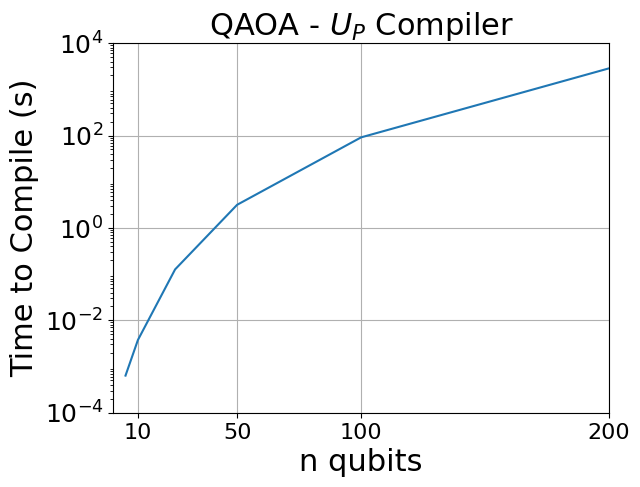

In [3]:
n_list = [5,10,25,50,100,200]

time_list_qaoa_up = []
with open('Data/qaoa_up_times.txt','r') as f:
    for line in f.readlines():
        time_list_qaoa_up.append(float(line.split(',')[1]))

plt.plot(n_list, time_list_qaoa_up)
plt.ylabel('Time to Compile (s)', fontsize = 22)
plt.title(r'QAOA - $U_P$ Compiler', fontsize = 22)
plt.yscale('log')
plt.xlabel('n qubits', fontsize = 22)
plt.xticks([10, 50, 100, 200], [10, 50, 100, 200], fontsize = 16)
plt.grid()
plt.ylim((1e-4,1e4))
plt.xlim((0,200))
plt.yticks([1e-4, 1e-2, 1e0, 1e2, 1e4], fontsize = 18)
plt.savefig('Figures/time_ qaoa_up.pdf', bbox_inches='tight')

# QAOA - $U_X$

In [ ]:
n_list = [2,5,10,25,50,100,200]
time_list_qaoa_ux = []
beta = 1

for n in n_list:
    start = time.time()
    ux_gates = generate_qaoa_ux_gates(n, beta)

    ux_data = generate_qaoa_ux_lhz_spanning_lines(
        n,
        up_spanning_data=up_data,
        return_cnot_steps=True,
    )

    compiled_ux, debug_ux = compile_qaoa_ux_with_lhz_spanning_lines(
        ux_gates,
        n,
        ux_spanning_data=ux_data,
        return_debug=True,
        verbose=False,
    )
    stop = time.time()
    time_list_qaoa_ux.append(stop-start)

    with open('Data/qaoa_ux_times.txt','w') as f:
        for idx, t in enumerate(time_list_qaoa_ux):
            f.write(f'{n_list[idx]},{str(t)}')
            f.write('\n')

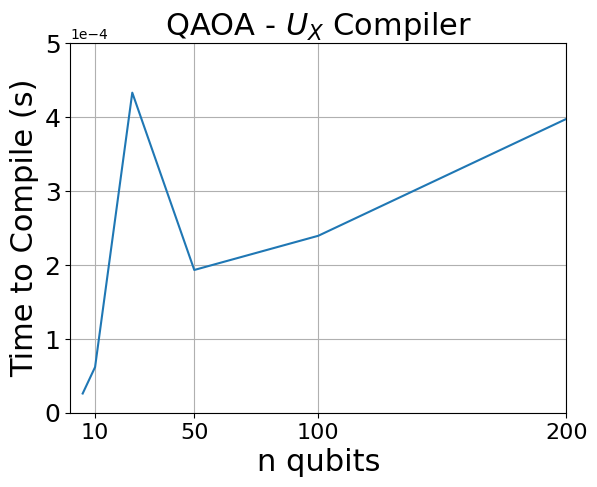

In [4]:
n_list = [5,10,25,50,100,200]

time_list_qaoa_ux = []
with open('Data/qaoa_ux_times.txt','r') as f:
    for line in f.readlines():
        time_list_qaoa_ux.append(float(line.split(',')[1]))

plt.plot(n_list, time_list_qaoa_ux)
plt.ylabel('Time to Compile (s)', fontsize = 22)
plt.title(r'QAOA - $U_X$ Compiler', fontsize = 22)
plt.xlabel('n qubits', fontsize = 22)
plt.xticks([10, 50, 100, 200], [10, 50, 100, 200], fontsize = 16)
plt.grid()
plt.ylim((0,5e-4))
plt.xlim((0,200))
plt.ticklabel_format(axis='y', style='sci', scilimits=(-4,-4))
plt.yticks([0,1e-4, 2e-4, 3e-4, 4e-4, 5e-4], fontsize = 18)
plt.savefig('Figures/time_ qaoa_ux.pdf', bbox_inches='tight')